# ResNet-50 Binary Classifier — PatchCamelyon (PCam)
**Deep Learning Course Project**

Binary classification of histopathology patches (metastatic / non-metastatic) using a frozen ResNet-50 backbone with a trainable classification head.

---


## 1. Environment Setup

In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cse493g1/assignments/assignment5/'
FOLDERNAME = 'cse493g/project/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Create a local folder on the Colab VM
!mkdir -p /content/local_data

# Copy the HDF5 files from Google Drive to the fast local disk
# to save training time as currently drive file access is the bottleneck
!cp -r /content/drive/MyDrive/cse493g/project/data/*.h5 /content/local_data/

print("Copy complete!")

Copy complete!


In [ ]:
import os
import random

import numpy as np
import h5py

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.models as models
import torchvision.transforms as transforms

from sklearn.metrics import roc_auc_score

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device ─────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


## 2. Configuration
All hyperparameters and file paths are defined here. Edit this cell to change any setting.

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR = "/content/local_data"        # directory containing the .h5 files
CHECKPOINT_PATH = "/content/drive/MyDrive/cse493g/best_resnet50.pt"

# ── File names ─────────────────────────────────────────────────────────────────
FILES = {
    "train": {
        "x": os.path.join(DATA_DIR, "camelyonpatch_level_2_split_train_x.h5"),
        "y": os.path.join(DATA_DIR, "camelyonpatch_level_2_split_train_y.h5"),
    },
    "val": {
        "x": os.path.join(DATA_DIR, "camelyonpatch_level_2_split_valid_x.h5"),
        "y": os.path.join(DATA_DIR, "camelyonpatch_level_2_split_valid_y.h5"),
    },
    "test": {
        "x": os.path.join(DATA_DIR, "camelyonpatch_level_2_split_test_x.h5"),
        "y": os.path.join(DATA_DIR, "camelyonpatch_level_2_split_test_y.h5"),
    },
}

# ── Training hyperparameters ───────────────────────────────────────────────────
BATCH_SIZE    = 64
LEARNING_RATE = 1e-3
NUM_EPOCHS    = 10       # increase to 20 for a full run
DROPOUT_RATE  = 0.5

# ── Architecture ───────────────────────────────────────────────────────────────
BACKBONE_OUT_DIM = 2048   # ResNet-50 global avg-pool output dimension
HEAD_HIDDEN_DIM  = 512

print("Configuration loaded.")
print(f"  Data directory : {DATA_DIR}")
print(f"  Checkpoint     : {CHECKPOINT_PATH}")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  Learning rate  : {LEARNING_RATE}")
print(f"  Epochs         : {NUM_EPOCHS}")


Configuration loaded.
  Data directory : /content/local_data
  Checkpoint     : /content/drive/MyDrive/cse493g/best_resnet50.pt
  Batch size     : 64
  Learning rate  : 0.001
  Epochs         : 10


## 3. Dataset & DataLoaders

`PCamDataset` reads images and labels lazily from HDF5 files (one sample at a time) to avoid loading the full dataset into RAM.

- Images: shape `(96, 96, 3)` uint8 → cast to float32, divided by 255, permuted to `(3, 96, 96)`
- Labels: shape `(1, 1, 1)` uint8 → squeezed to scalar float32


In [ ]:
class PCamDataset(Dataset):
    """Lazy-loading Dataset for PatchCamelyon HDF5 files."""

    def __init__(self, x_path: str, y_path: str, transform=None):
        self.x_path = x_path
        self.y_path = y_path
        self.transform = transform

        # Placeholders for our file handles
        self.fx = None
        self.fy = None

        # Read length only
        with h5py.File(x_path, "r") as f:
            self.length = f["x"].shape[0]

    def __len__(self) -> int:
        return self.length

    def __getitem__(self, idx):
        # Open the file only ONCE per worker process, then keep it open
        if self.fx is None:
            self.fx = h5py.File(self.x_path, "r")
        if self.fy is None:
            self.fy = h5py.File(self.y_path, "r")

        # Read the data using the open file handles
        image = self.fx["x"][idx]
        label = int(self.fy["y"][idx].squeeze())

        # Normalise to [0, 1] and convert to (C, H, W) float tensor
        image = image.astype(np.float32) / 255.0
        image = torch.tensor(image).permute(2, 0, 1)  # (3, 96, 96)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)


# ── Transforms ─────────────────────────────────────────────────────────────────
_imagenet_norm = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    _imagenet_norm,
])

eval_transform = transforms.Compose([
    _imagenet_norm,
])

# ── Instantiate datasets ────────────────────────────────────────────────────────
train_dataset = PCamDataset(FILES["train"]["x"], FILES["train"]["y"], transform=train_transform)
val_dataset   = PCamDataset(FILES["val"]["x"],   FILES["val"]["y"],   transform=eval_transform)
test_dataset  = PCamDataset(FILES["test"]["x"],  FILES["test"]["y"],  transform=eval_transform)

print(f"Dataset sizes  →  train: {len(train_dataset):,}  |  val: {len(val_dataset):,}  |  test: {len(test_dataset):,}")

# ── DataLoaders ────────────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Batches per epoch  →  train: {len(train_loader):,}  |  val: {len(val_loader):,}  |  test: {len(test_loader):,}")


Dataset sizes  →  train: 262,144  |  val: 32,768  |  test: 32,768
Batches per epoch  →  train: 4,096  |  val: 512  |  test: 512


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 4. Model Definition

**Backbone:** RestNet-50 loaded with ImageNet weights. All backbone parameters are frozen immediately after loading. The original classifier is replaced with `nn.Identity()` so the backbone outputs a 2048-dimensional feature vector.

**Head:** A small MLP trained from scratch:
```
Linear(2048, 512) → ReLU → Dropout(0.5) → Linear(512, 1) → Sigmoid
```


In [ ]:
# ── Backbone ───────────────────────────────────────────────────────────────────
backbone = models.resnet50(weights="IMAGENET1K_V1")

# Freeze ALL backbone parameters
for param in backbone.parameters():
    param.requires_grad = False

# Remove original classifier; backbone now outputs (batch, 2048)
backbone.fc = nn.Identity()

# ── Classification Head ────────────────────────────────────────────────────────
head = nn.Sequential(
    nn.Linear(BACKBONE_OUT_DIM, HEAD_HIDDEN_DIM),
    nn.ReLU(),
    nn.Dropout(DROPOUT_RATE),
    nn.Linear(HEAD_HIDDEN_DIM, 1),
    nn.Sigmoid(),
)


# ── Full Model ─────────────────────────────────────────────────────────────────
class ResNetClassifier(nn.Module):
    """Frozen ResNet-50 backbone + trainable MLP classification head."""

    def __init__(self, backbone: nn.Module, head: nn.Module):
        super().__init__()
        self.backbone = backbone
        self.head = head

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.backbone(x)      # (batch, 2048)
        return self.head(features)       # (batch, 1)


model = ResNetClassifier(backbone, head).to(DEVICE)

# ── Parameter verification ─────────────────────────────────────────────────────
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
frozen    = total - trainable

print(f"Total parameters     : {total:>12,}")
print(f"Frozen (backbone)    : {frozen:>12,}")
print(f"Trainable (head)     : {trainable:>12,}")
assert trainable < total, "ERROR: backbone parameters should be frozen."
print("\nBackbone frozen successfully. Only head parameters will be trained.")


Total parameters     :   24,557,633
Frozen (backbone)    :   23,508,032
Trainable (head)     :    1,049,601

Backbone frozen successfully. Only head parameters will be trained.


## 5. Training Loop

Defines `train_one_epoch` (single pass over training data) and the outer `train` loop that:
- Runs each epoch
- Evaluates on the validation set after every epoch
- Saves the best model checkpoint based on validation accuracy


In [ ]:
# ── Loss & Optimizer ───────────────────────────────────────────────────────────
# BCELoss is used with Sigmoid output in the head
criterion = nn.BCELoss()

# Pass ONLY trainable (head) parameters to the optimizer
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
)


def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run one full pass over the training DataLoader. Returns mean loss and accuracy."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i,  (images, labels) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = (outputs >= 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if (i + 1) % 100 == 0:
            current_loss = running_loss / total
            current_acc = correct / total
            print(f"   Batch [{i+1:>4}/{len(loader)}]  "
                  f"Loss: {current_loss:.4f}  "
                  f"Acc: {current_acc:.4f}")

    return running_loss / len(loader.dataset), correct / total


def train(model, train_loader, val_loader, criterion, optimizer,
          num_epochs, device, checkpoint_path):
    history = {"train_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_acc = evaluate(model, val_loader, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        saved = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), checkpoint_path)
            saved = "  ← best checkpoint saved"

        print(
            f"Epoch [{epoch:>{len(str(num_epochs))}}/{num_epochs}]  "
            f"Loss: {train_loss:.4f}  "
            f"Train Acc: {train_acc:.4f}  "
            f"Val Acc: {val_acc:.4f}"
            f"{saved}"
        )

    return history, best_val_acc


## 6. Validation Helper

`evaluate` runs inference in `torch.no_grad()` mode and returns classification accuracy. It is reused for both per-epoch validation and final test evaluation.


In [ ]:
def evaluate(model, loader, device):
    """
    Compute classification accuracy over a DataLoader.

    Parameters
    ----------
    model  : nn.Module
    loader : DataLoader
    device : torch.device

    Returns
    -------
    accuracy : float in [0, 1]
    """
    model.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images).squeeze(1)        # (batch,)
            preds   = (outputs >= 0.5).float()        # threshold at 0.5
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    return correct / total

print("evaluate() helper defined.")


evaluate() helper defined.


In [ ]:
!nvidia-smi

Sun Mar 15 00:33:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             29W /   70W |     685MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 7. Run Training

Executes the training loop. The best model checkpoint (based on validation accuracy) is saved to `CHECKPOINT_PATH`.


In [ ]:
history, best_val_acc = train(
    model       = model,
    train_loader= train_loader,
    val_loader  = val_loader,
    criterion   = criterion,
    optimizer   = optimizer,
    num_epochs  = NUM_EPOCHS,
    device      = DEVICE,
    checkpoint_path = CHECKPOINT_PATH,
)

print(f"\nTraining complete.")
print(f"Best validation accuracy : {best_val_acc:.4f}")
print(f"Checkpoint saved to      : {CHECKPOINT_PATH}")


   Batch [ 100/4096]  Loss: 0.3956  Acc: 0.8228
   Batch [ 200/4096]  Loss: 0.3928  Acc: 0.8234
   Batch [ 300/4096]  Loss: 0.3929  Acc: 0.8243
   Batch [ 400/4096]  Loss: 0.3901  Acc: 0.8251
   Batch [ 500/4096]  Loss: 0.3912  Acc: 0.8252
   Batch [ 600/4096]  Loss: 0.3903  Acc: 0.8252
   Batch [ 700/4096]  Loss: 0.3904  Acc: 0.8250
   Batch [ 800/4096]  Loss: 0.3905  Acc: 0.8246
   Batch [ 900/4096]  Loss: 0.3903  Acc: 0.8251
   Batch [1000/4096]  Loss: 0.3910  Acc: 0.8246
   Batch [1100/4096]  Loss: 0.3908  Acc: 0.8245
   Batch [1200/4096]  Loss: 0.3908  Acc: 0.8246
   Batch [1300/4096]  Loss: 0.3903  Acc: 0.8246
   Batch [1400/4096]  Loss: 0.3899  Acc: 0.8250
   Batch [1500/4096]  Loss: 0.3902  Acc: 0.8246
   Batch [1600/4096]  Loss: 0.3905  Acc: 0.8241
   Batch [1700/4096]  Loss: 0.3905  Acc: 0.8242
   Batch [1800/4096]  Loss: 0.3905  Acc: 0.8243
   Batch [1900/4096]  Loss: 0.3903  Acc: 0.8242
   Batch [2000/4096]  Loss: 0.3907  Acc: 0.8241
   Batch [2100/4096]  Loss: 0.3905  Acc:

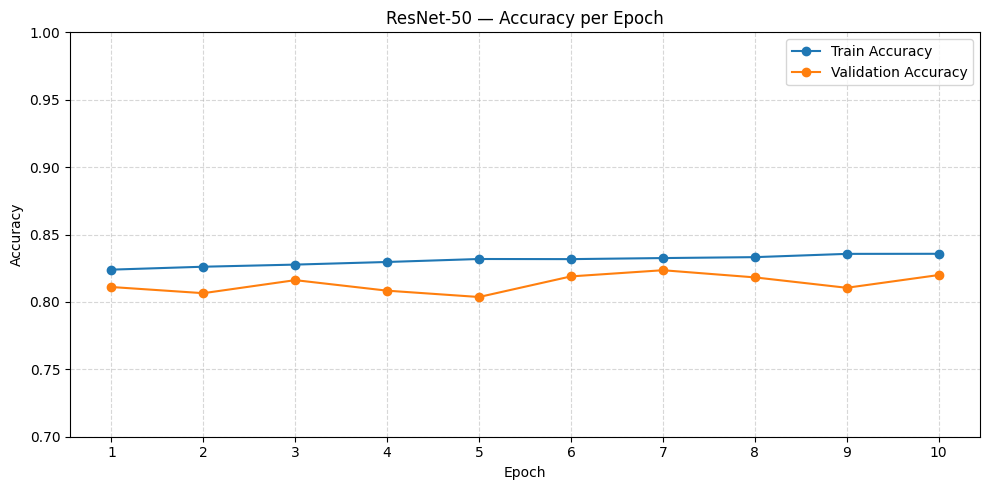

Plot saved to Drive.


In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(epochs, history["val_acc"],   marker="o", label="Validation Accuracy")

# Fixed the "RestNet" typos below!
plt.title("ResNet-50 — Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)

plt.ylim(0.7, 1)

plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

# Saving to your cse493g folder next to your .pt checkpoint!
plt.savefig("/content/drive/MyDrive/cse493g/ResNet-50_accuracy_curve.png", dpi=150)
plt.show()

print("Plot saved to Drive.")

## 8. Test Evaluation

Loads the best saved checkpoint and evaluates on the held-out test set.

- **Test Accuracy**: sigmoid output thresholded at 0.5
- **Test AUC-ROC**: raw sigmoid probabilities passed to `sklearn.metrics.roc_auc_score`


In [ ]:
# ── Load best checkpoint ───────────────────────────────────────────────────────
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()

all_probs  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        probs  = model(images).squeeze(1).cpu().numpy()   # raw probabilities
        all_probs.extend(probs.tolist())
        all_labels.extend(labels.numpy().tolist())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

# ── Metrics ────────────────────────────────────────────────────────────────────
test_acc = float(((all_probs >= 0.5).astype(float) == all_labels).mean())
test_auc = float(roc_auc_score(all_labels, all_probs))

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test AUC-ROC  : {test_auc:.4f}")


Test Accuracy : 0.7810
Test AUC-ROC  : 0.8883


## 9. Results Summary


In [ ]:
print("=" * 47)
print(f"{'Backbone':<22} {'Test Acc':>10} {'Test AUC':>10}")
print("-" * 47)
print(f"{'ResNet-50':<22} {test_acc:>10.4f} {test_auc:>10.4f}")
print("=" * 47)


Backbone                 Test Acc   Test AUC
-----------------------------------------------
ResNet-50                  0.7810     0.8883
